# Exploring regimes in the S&P 500

A short, honest walk through the data before any modelling. Everything here is descriptive and in-sample. The predictive study, with purged walk-forward validation, lives in `meridian/report.py`. Research, not financial advice.

In [ ]:
import sys, tempfile
from pathlib import Path

sys.path.insert(0, '..')
import numpy as np
import pandas as pd
from IPython.display import Image, display

from meridian import data, features, plotting, regimes, report, stats

df = data.load(data.DEFAULT_SERIES, '1990-01-01')
print(df.index.min().date(), df.index.max().date(), len(df))
df.tail()

## Features are backward-looking only

Every column at row *t* is computed from rows up to *t*. Targets look forward and are kept in a separate frame.

In [ ]:
X = features.build(df)
X.describe().T[['mean', 'std', 'min', 'max']].round(3)

## Why regimes: volatility clusters

A Ljung-Box test on daily returns versus squared returns. Both reject independence, but the squared-returns statistic is far larger: the size of moves is more persistent than their direction, which is what a regime-switching volatility model is built to capture.

In [ ]:
r = np.log(df['SP500']).diff().dropna()
print('returns         Q, p =', stats.ljung_box(r))
print('squared returns Q, p =', stats.ljung_box(r**2))

## Fitting the regimes

A three-state Gaussian HMM on realised volatility, VIX and 21-day momentum. States are ordered by volatility. The labels shown here are Viterbi-smoothed over the full sample, so they use hindsight: fine for a picture, never an input to a model.

In [ ]:
Xr = X[features.REGIME_COLUMNS].dropna()
labels, model = regimes.fit_hmm(Xr, k=3, seed=0)
ret = r.loc[labels.index]
pd.DataFrame({
    'share': labels.value_counts(normalize=True).sort_index(),
    'ann_vol': ret.groupby(labels).std() * np.sqrt(252),
    'avg_spell_days': report.run_lengths(labels),
}).round(3)

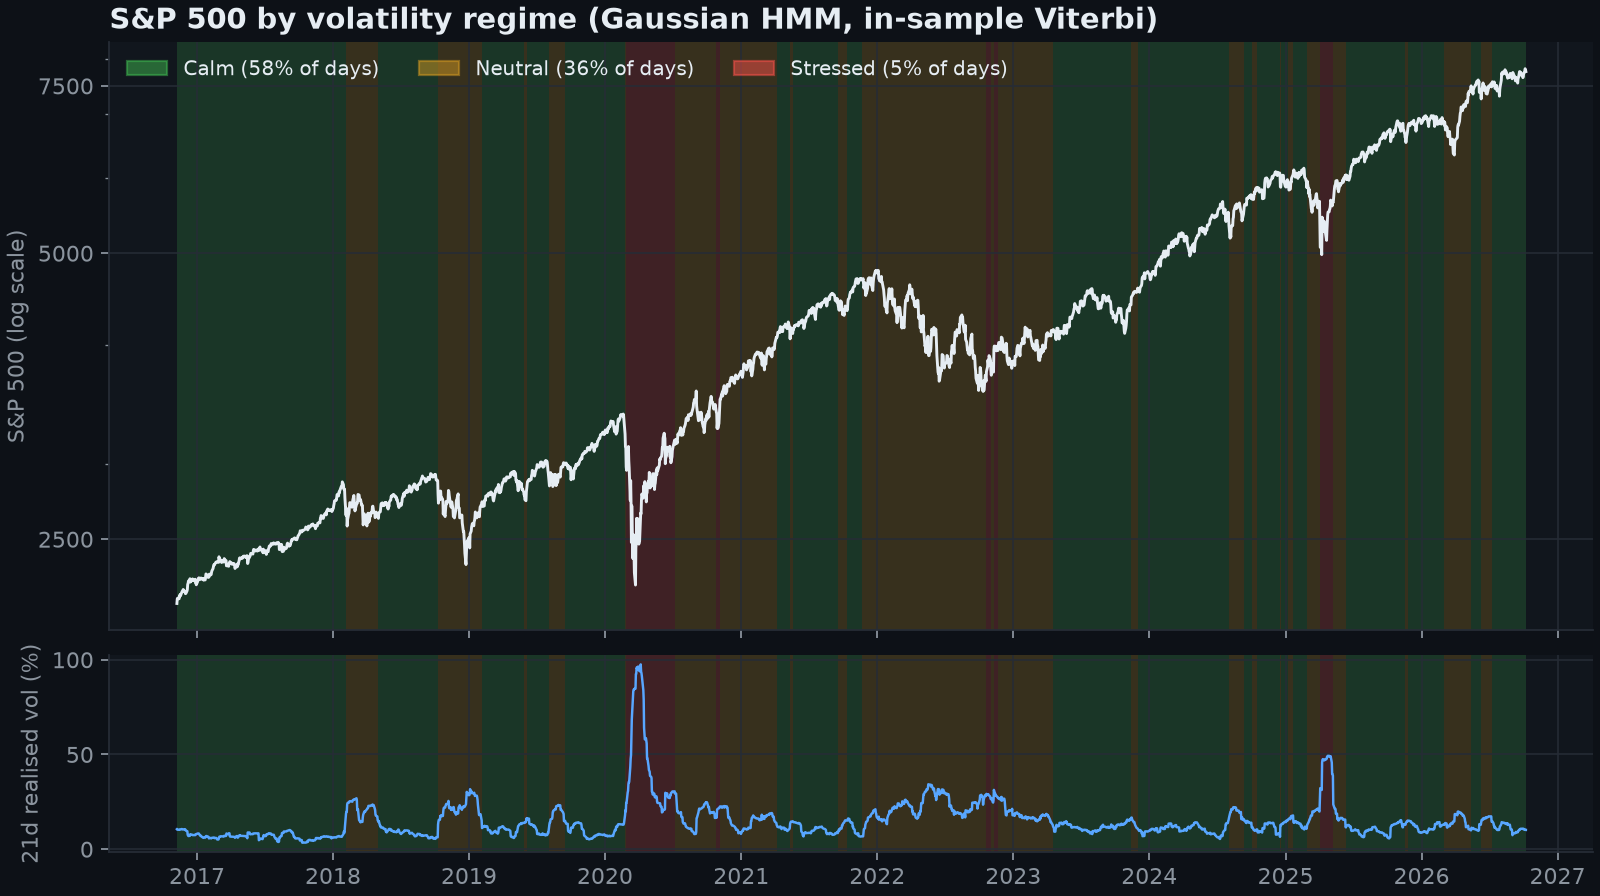

In [ ]:
out = Path(tempfile.mkdtemp())
fig = plotting.plot_regimes(df['SP500'].loc[labels.index], labels, X['rv21'].loc[labels.index],
                            'S&P 500 by volatility regime (Gaussian HMM, in-sample Viterbi)')
display(Image(filename=plotting.save(fig, out / 'regimes.png')))

## What the regimes imply for the next month

Forward 21-day returns by regime. The target here is the *label* the models later try to predict, so this is a description of the problem and not a tradable rule.

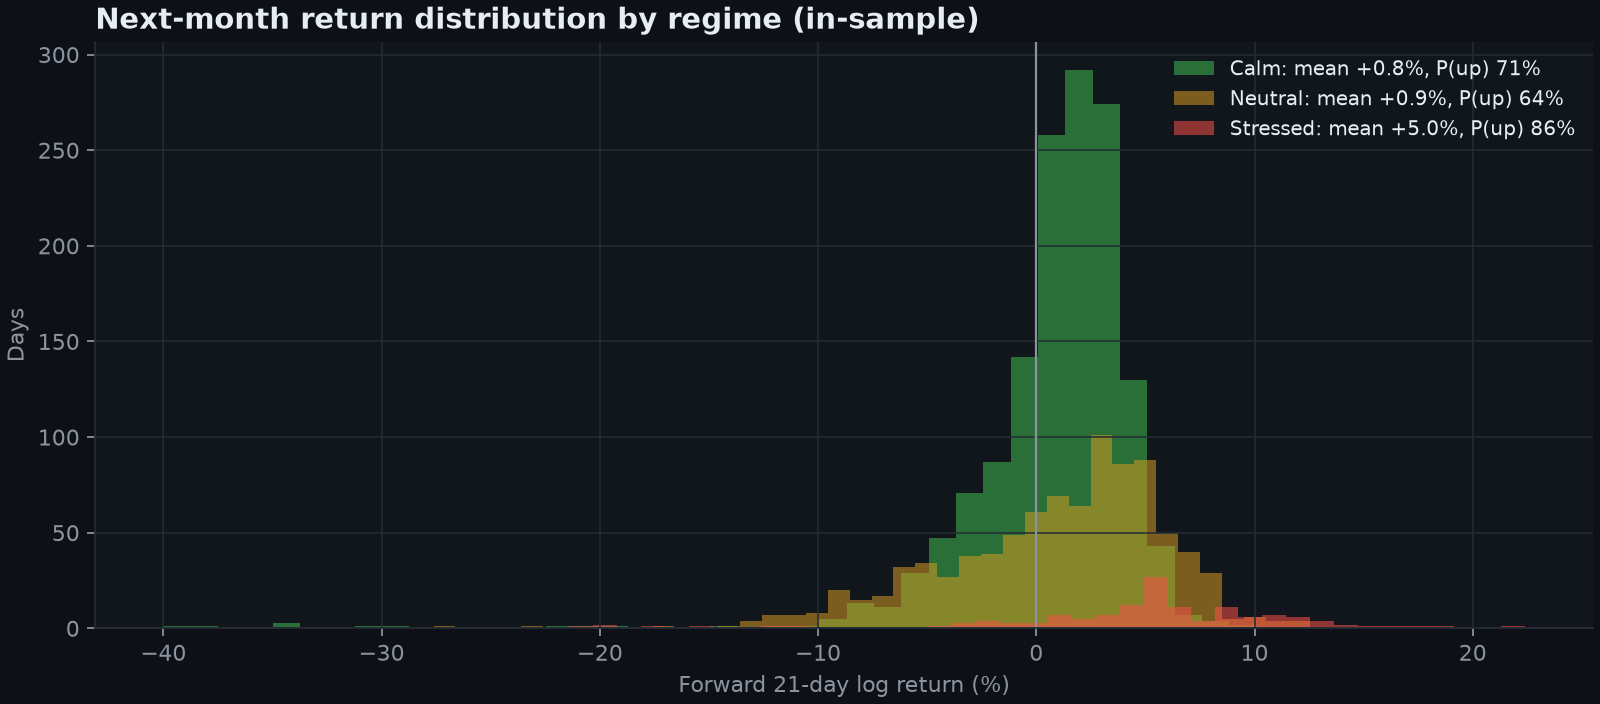

In [ ]:
fwd = features.targets(df, 21)['fwd_ret'].loc[labels.index].dropna()
fig, ax = plotting.new_figure(4.4)
for k in range(3):
    v = fwd[labels.loc[fwd.index] == k] * 100
    ax.hist(v, bins=40, alpha=0.55, color=plotting.REGIME_COLORS[k],
            label=f'{plotting.REGIME_NAMES[k]}: mean {v.mean():+.1f}%, P(up) {(v > 0).mean():.0%}')
ax.axvline(0, color=plotting.MUTED, lw=1)
ax.set_xlabel('Forward 21-day log return (%)'); ax.set_ylabel('Days')
ax.set_title('Next-month return distribution by regime (in-sample)')
ax.legend()
display(Image(filename=plotting.save(fig, out / 'forward.png')))